# SVM: Pilot positive control (Ictal vs. pre-ictal: 1 min)
mi novia se cayo en pozo ciego - los fabulosos cadillacs

## 1. input
Table with A. features, B. label and C. Metadata. 

**A. Feature columns:** 
These go into the model. Training. These enter into the SVM

**B. Label column:**
This is the target only.

**C. Metadata column:**
These are used for tracking, splitting, and interpretation, but not for training.


In [1]:
# Importing the df from pickle
import pandas as pd
from pathlib import Path
# Load the feature dataframe from the pickle file
import pandas as pd
df_features = pd.read_pickle("/home/tperezsanchez/FoundationModel_EEG_Dissertation/Main_project/results/RQXZ1/Feature_ext/Part2_features/RQXZ1_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260510_v01_FEAT-TIME-FREQ_20260510_v01/RQXZ1_IN-normalized_npz_FP-fullnpz_W10s_PRE6to5min_ICT0to1min_GAPasINT_FINAL-PREvsSEIZ_20260510_v01_FEAT-TIME-FREQ_20260510_v01_df_features_ictalVspreictal.pkl")

df_features.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,RQXZ1_348_preproc_full.npz,384,794880,796950,207.031055,2,10,[2021-01-25 22:09:33.000000],2021-01-25 22:03:26.423999874,2021-01-25 22:03:36.422499874,...,0.009333,0.017330,0.005018,1.000150,0.020635,0.021386,0.017917,0.057057,0.017111,1.500225
1,RQXZ1_348_preproc_full.npz,385,796950,799020,207.031055,2,10,[2021-01-25 22:09:33.000000],2021-01-25 22:03:36.422499874,2021-01-25 22:03:46.420999874,...,0.012844,0.018002,0.005159,0.500075,0.020700,0.017561,0.012600,0.065202,0.020605,1.000150
2,RQXZ1_348_preproc_full.npz,386,799020,801090,207.031055,2,10,[2021-01-25 22:09:33.000000],2021-01-25 22:03:46.420999874,2021-01-25 22:03:56.419499873,...,0.020102,0.022407,0.006948,1.000150,0.038508,0.028938,0.022923,0.061004,0.025144,1.000150
3,RQXZ1_348_preproc_full.npz,387,801090,803160,207.031055,2,10,[2021-01-25 22:09:33.000000],2021-01-25 22:03:56.419499873,2021-01-25 22:04:06.417999873,...,0.008454,0.017888,0.005391,1.000150,0.014299,0.011431,0.014290,0.051468,0.018759,1.500225
4,RQXZ1_348_preproc_full.npz,388,803160,805230,207.031055,2,10,[2021-01-25 22:09:33.000000],2021-01-25 22:04:06.417999873,2021-01-25 22:04:16.416499873,...,0.011653,0.021627,0.005459,0.500075,0.020368,0.011998,0.016521,0.055766,0.016282,1.000150


## 2. Sorting by time
  -  "interictal": 0,
  -  "preictal": 1,
  -  "seizure": 2

In [3]:
df_SVM = df_features.copy()
df_SVM["window_start_time"] = pd.to_datetime(df_SVM["window_start_time"])
df_SVM = df_SVM.sort_values("window_start_time").reset_index(drop=True)

In [4]:
print(df_SVM["window_start_time"].head())
print(df_SVM["window_start_time"].tail())
# it checks with mapping, as it is the last day of recording (2019-12-13)

0   2021-01-25 22:03:26.423999874
1   2021-01-25 22:03:36.422499874
2   2021-01-25 22:03:46.420999874
3   2021-01-25 22:03:56.419499873
4   2021-01-25 22:04:06.417999873
Name: window_start_time, dtype: datetime64[ns]
2438   2021-07-10 02:21:51.756499729
2439   2021-07-10 02:22:01.754999729
2440   2021-07-10 02:22:11.753499729
2441   2021-07-10 02:22:21.751999728
2442   2021-07-10 02:22:31.750499728
Name: window_start_time, dtype: datetime64[ns]


In [4]:
df_SVM.head()

,file_name,window_id,start_sample,end_sample,fs,n_channels,window_sec,seizure_onsets,window_start_time,window_end_time,...,alpha_power_EEG_SQ_D_SQ_C,beta_power_EEG_SQ_D_SQ_C,gamma_power_EEG_SQ_D_SQ_C,peak_frequency_EEG_SQ_D_SQ_C,delta_power_EEG_SQ_P_SQ_C,theta_power_EEG_SQ_P_SQ_C,alpha_power_EEG_SQ_P_SQ_C,beta_power_EEG_SQ_P_SQ_C,gamma_power_EEG_SQ_P_SQ_C,peak_frequency_EEG_SQ_P_SQ_C
0,XB47Y_41_preproc_full.npz,1278,2645460,2647530,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:03.082999583,2019-10-31 23:19:13.081499583,...,0.002582,0.019144,0.006566,1.000150,0.013596,0.003118,0.007933,0.021500,0.006653,1.000150
1,XB47Y_41_preproc_full.npz,1279,2647530,2649600,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:13.081499583,2019-10-31 23:19:23.079999582,...,0.025909,0.075080,0.035583,1.000150,0.374413,0.020533,0.039268,0.397410,0.130566,0.500075
2,XB47Y_41_preproc_full.npz,1280,2649600,2651670,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:23.079999582,2019-10-31 23:19:33.078499582,...,0.008247,0.142228,0.049720,1.000150,0.026109,0.004368,0.020448,0.253664,0.104950,29.004351
3,XB47Y_41_preproc_full.npz,1281,2651670,2653740,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:33.078499582,2019-10-31 23:19:43.076999582,...,0.005990,0.156501,0.061811,24.503676,0.023547,0.009824,0.015228,0.274218,0.111887,24.503676
4,XB47Y_41_preproc_full.npz,1282,2653740,2655810,207.031055,2,10,[2019-10-31 23:25:08.153000],2019-10-31 23:19:43.076999582,2019-10-31 23:19:53.075499581,...,0.006253,0.167084,0.086315,19.002850,0.018473,0.005101,0.012831,0.262820,0.175828,18.502775


In [5]:
print("Rows before:", len(df_SVM))
print("NaNs per column:\n", df_SVM.isna().sum().sort_values(ascending=False).head(20))
print("Rows with any NaN:", df_SVM.isna().any(axis=1).sum())

Rows before: 2443
NaNs per column:
 excluded_reason              2443
window_id                       0
start_sample                    0
end_sample                      0
fs                              0
n_channels                      0
window_sec                      0
seizure_onsets                  0
file_name                       0
window_start_time               0
window_end_time                 0
class_label                     0
label_name                      0
mean_EEG_SQ_D_SQ_C              0
std_EEG_SQ_D_SQ_C               0
var_EEG_SQ_D_SQ_C               0
rms_EEG_SQ_D_SQ_C               0
ptp_EEG_SQ_D_SQ_C               0
line_length_EEG_SQ_D_SQ_C       0
skew_EEG_SQ_D_SQ_C              0
dtype: int64
Rows with any NaN: 2443


In [6]:
df_SVM = df_SVM.dropna(axis=1, how="all").copy()

metadata_cols = [
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "file_name",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name"
]

feature_cols = [col for col in df_SVM.columns if col not in metadata_cols]

X = df_SVM[feature_cols].copy()
y = df_SVM["class_label"].copy()

print("df_SVM shape:", df_SVM.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

df_SVM shape: (2443, 40)
X shape: (2443, 28)
y shape: (2443,)
NaNs in X: 0
Class counts:
class_label
2    1239
1    1204
Name: count, dtype: int64


In [7]:
df_SVM.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443 entries, 0 to 2442
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   file_name                     2443 non-null   object        
 1   window_id                     2443 non-null   int64         
 2   start_sample                  2443 non-null   int64         
 3   end_sample                    2443 non-null   int64         
 4   fs                            2443 non-null   float64       
 5   n_channels                    2443 non-null   int64         
 6   window_sec                    2443 non-null   int64         
 7   seizure_onsets                2443 non-null   object        
 8   window_start_time             2443 non-null   datetime64[ns]
 9   window_end_time               2443 non-null   datetime64[ns]
 10  class_label                   2443 non-null   int64         
 11  label_name                    

In [8]:
import numpy as np

# -------------------------------
# 1. Define target variable
# -------------------------------
y = df_SVM["class_label"].copy()

# -------------------------------
# 2. Drop metadata, identifiers, temporal info, target columns,
#    and columns that are not EEG-derived features
# -------------------------------
cols_to_drop = [
    "file_name",
    "window_id",
    "start_sample",
    "end_sample",
    "fs",
    "n_channels",
    "window_sec",
    "seizure_onsets",
    "window_start_time",
    "window_end_time",
    "class_label",
    "label_name",
    "excluded_reason"   # important: this column is completely empty
]

# Drop only columns that actually exist
cols_to_drop = [col for col in cols_to_drop if col in df_SVM.columns]

X = df_SVM.drop(columns=cols_to_drop).copy()

# -------------------------------
# 3. Keep only numeric EEG-derived features
# -------------------------------
X = X.select_dtypes(include=[np.number])

# -------------------------------
# 4. Replace infinite values with NaN
# -------------------------------
X = X.replace([np.inf, -np.inf], np.nan)

# -------------------------------
# 5. Keep only rows without missing values in EEG features
# -------------------------------
mask = X.notna().all(axis=1)

X = X.loc[mask].copy()
y = y.loc[mask].copy()

# -------------------------------
# 6. Remove constant columns
# -------------------------------
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

# -------------------------------
# 7. Sanity checks
# -------------------------------
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Removed constant columns:", constant_cols)
print("Total NaNs in X:", X.isna().sum().sum())
print("Class counts:")
print(y.value_counts())

X shape: (2443, 28)
y shape: (2443,)
Removed constant columns: []
Total NaNs in X: 0
Class counts:
class_label
2    1239
1    1204
Name: count, dtype: int64


In [9]:
# Print final shapes
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

# Print feature names used for SVM
print("Features used:")
print(X.columns.tolist())

Final X shape: (2443, 28)
Final y shape: (2443,)
Features used:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']


In [10]:
# Convert labels to binary format:
# 0 = preictal
# 1 = seizure
y_binary = y.map({
    1: 0,
    2: 1
})

print(y_binary.value_counts())
y = y_binary.copy()

class_label
1    1239
0    1204
Name: count, dtype: int64


In [11]:
# y.mean() corresponds to the proportion of class 1 (seizure)
global_ratio = y.mean()
print("Global seizure ratio:", global_ratio)

Global seizure ratio: 0.5071633237822349


### 4.2 Search for best candidates for splitting

In [12]:
# Use the cleaned dataset size, not the original dataframe size
n = len(X)
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

ideal_train = 0.70
ideal_val = 0.15
ideal_test = 0.15

# generate candidates for the splitting

# possible positions where training ends
train_candidates = range(int(0.70 * n), int(0.90 * n), max(1, n // 1000))
# possible positions where validation ends 
val_candidates = range(int(0.05 * n), int(0.20 * n), max(1, n // 1000))

# search for the best temporal split
best = None
best_score = np.inf



In [13]:
# This procedure creates a temporal split by preserving the chronological order
# of the samples, while selecting the train/validation/test boundaries that
# best match the desired split proportions and maintain class ratios close to
# the global dataset distribution.
for train_end in train_candidates:
    for val_size in val_candidates:
        val_end = train_end + val_size

        if val_end >= n:
            continue

        # temporal subsets because df is already sorted by window_start_time
        # SPLIT STARTS HERE
        y_train = y.iloc[:train_end]
        y_val = y.iloc[train_end:val_end]
        y_test = y.iloc[val_end:]

        # require both classes in every split
        # MAKE SURE OF THE PRESENCE OF EACH CLASS IN EVERY SET
        if y_train.nunique() < 2 or y_val.nunique() < 2 or y_test.nunique() < 2:
            continue

        # size closeness to 75/15/15
        # measure how close is to the ideal proportion
        train_frac = len(y_train) / n
        val_frac = len(y_val) / n
        test_frac = len(y_test) / n

        size_score = (
            abs(train_frac - 0.70) +
            abs(val_frac - 0.15) +
            abs(test_frac - 0.15)
        )

        # class ratio closeness to global ratio
        # measure how close is the preictal proportions 
        ratio_score = (
            abs(y_train.mean() - global_ratio) +
            abs(y_val.mean() - global_ratio) +
            abs(y_test.mean() - global_ratio)
        )

        # combined score for choosing the best score
        score = size_score + ratio_score * 3

        if score < best_score:
            best_score = score
            best = (train_end, val_end)


In [14]:
# Unpack the best split boundaries found previously
# train_end = index where the training set stops
# val_end = index where the validation set stops
train_end, val_end = best

# Create the training set:
# from the beginning of the dataset up to train_end (excluded)
X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

# Create the validation set:
# from train_end up to val_end (excluded)
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

# Create the test set:
# from val_end to the end of the dataset
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

In [15]:
print("\nSet sizes:")
print(f"Train: {len(X_train)} ({len(X_train)/n:.3%})")
print(f"Val:   {len(X_val)} ({len(X_val)/n:.3%})")
print(f"Test:  {len(X_test)} ({len(X_test)/n:.3%})")

print("\nPreictal ratios:")
print(f"Global: {y.mean():.5f}")
print(f"Train:  {y_train.mean():.5f}")
print(f"Val:    {y_val.mean():.5f}")
print(f"Test:   {y_test.mean():.5f}")

print("\nTime ranges:")
print("Train:", df_SVM.loc[0, "window_start_time"], "->", df_SVM.loc[train_end - 1, "window_start_time"])
print("Val:  ", df_SVM.loc[train_end, "window_start_time"], "->", df_SVM.loc[val_end - 1, "window_start_time"])
print("Test: ", df_SVM.loc[val_end, "window_start_time"], "->", df_SVM.loc[n - 1, "window_start_time"])


Set sizes:
Train: 1714 (70.160%)
Val:   360 (14.736%)
Test:  369 (15.104%)

Preictal ratios:
Global: 0.50716
Train:  0.50583
Val:    0.50833
Test:   0.51220

Time ranges:
Train: 2021-01-25 22:03:26.423999874 -> 2021-05-16 23:08:01.042499574
Val:   2021-05-16 23:08:11.040999574 -> 2021-05-23 19:40:07.580999691
Test:  2021-05-23 19:40:17.579499691 -> 2021-07-10 02:22:31.750499728


## 5. Scaling features

SVM is very sensitive to feature scale.

If one feature has values around 1000 and another around 0.01, the large-scale feature will dominate the geometry.

Use standardization:

subtract mean
divide by standard deviation

In [14]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()

#X_train_scaled = scaler.fit_transform(X_train)
#X_val_scaled   = scaler.transform(X_val)
#X_test_scaled  = scaler.transform(X_test)


## 6. Linear SVC
SVM + class_weight='balanced'

In [25]:
import time
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
best_c = None
best_val_score = 0
c_values = [0.01, 0.1, 1, 10, 100,1000,10000,1000000]

for c in c_values:
    model = LinearSVC(C=c, class_weight='balanced', max_iter=10000)
    model.fit(X_train, y_train)
    
    score = model.score(X_val, y_val) 
    print(score)
    if score > best_val_score:
        best_val_score = score
        best_c = c

print(f"Best C: {best_c}")
# train model using the Best C, among the ones that I tried 

0.49722222222222223
0.5
0.5
0.4888888888888889
0.5
0.49444444444444446
0.49444444444444446
0.49444444444444446
Best C: 0.1


### 6.1 Linear with C=1: Training 


In [28]:
import time
from sklearn.svm import LinearSVC

model = LinearSVC(C=1.0, class_weight='balanced')
start = time.time()

model.fit(X_train, y_train)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")
# expected : Training time: 3.37 secondsfrom sklearn.metrics import classification_report
y_val_pred = model.predict(X_val)

print(f"\nC = {model.C}")
print(classification_report(y_val, y_val_pred))

Training time: 0.02 seconds

C = 1.0
              precision    recall  f1-score   support

           0       0.49      0.68      0.57       177
           1       0.51      0.33      0.40       183

    accuracy                           0.50       360
   macro avg       0.50      0.50      0.49       360
weighted avg       0.50      0.50      0.48       360



### 6.2 Evaluation of linear 

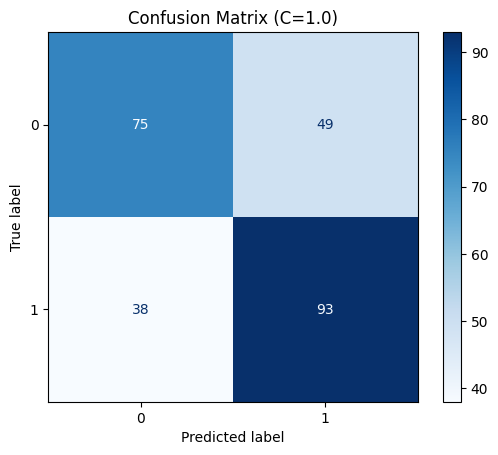

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

plt.title(f"Confusion Matrix (C={model.C})")
plt.show()

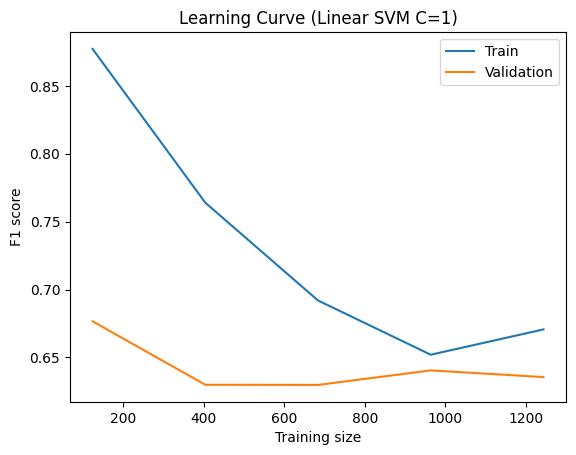

In [59]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1',   # importante en tu caso
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train")
plt.plot(train_sizes, val_mean, label="Validation")
plt.xlabel("Training size")
plt.ylabel("F1 score")
plt.title("Learning Curve (Linear SVM C=1)")
plt.legend()
plt.show()

## 7. RBF SVC

In [23]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, recall_score

# -----------------------------
# Define scoring metric
# -----------------------------
# Optimize recall for the positive class (class 1)
recall_pos1 = make_scorer(recall_score, pos_label=1)

# -----------------------------
# Build pipeline
# -----------------------------
# StandardScaler is included inside the pipeline
# so scaling is learned only from the training folds
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# -----------------------------
# Define temporal cross-validation
# -----------------------------
# TimeSeriesSplit preserves temporal order inside training
tscv = TimeSeriesSplit(n_splits=4)

# -----------------------------
# Define hyperparameter grid
# -----------------------------
# Intermediate-sized search for C and gamma
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# -----------------------------
# Grid search
# -----------------------------
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=recall_pos1,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# -----------------------------
# Fit grid search on training set only
# -----------------------------
grid.fit(X_train, y_train)

# -----------------------------
# Store best model
# -----------------------------
best_model = grid.best_estimator_

# -----------------------------
# Print best results
# -----------------------------
print("Best parameters:")
print(grid.best_params_)

print("\nBest mean CV recall (class 1):")
print(grid.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters:
{'svm__C': 0.1, 'svm__gamma': 1}

Best mean CV recall (class 1):
0.9112156244045797


In [18]:
# Convert CV results into a dataframe
results = pd.DataFrame(grid.cv_results_)

# Keep only useful columns
results = results[[
    "param_svm__C",
    "param_svm__gamma",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

print(results.head(10))

    param_svm__C param_svm__gamma  mean_test_score  std_test_score  \
4            0.1                1         0.921064        0.040556   
9            1.0                1         0.846191        0.056127   
19         100.0                1         0.835420        0.057382   
14          10.0                1         0.835271        0.060009   
13          10.0              0.1         0.777318        0.075584   
18         100.0              0.1         0.752721        0.090966   
15         100.0            scale         0.751677        0.102188   
3            0.1              0.1         0.740049        0.078730   
17         100.0             0.01         0.735801        0.091018   
10          10.0            scale         0.714408        0.072927   

    rank_test_score  
4                 1  
9                 2  
19                3  
14                4  
13                5  
18                6  
15                7  
3                 8  
17                9  
10       

In [19]:
from sklearn.metrics import recall_score

# Predict on validation set
y_val_pred = best_model.predict(X_val)

# Recall for positive class on validation
val_recall = recall_score(y_val, y_val_pred, pos_label=1)

print("Validation recall (class 1):", val_recall)

Validation recall (class 1): 0.9083969465648855


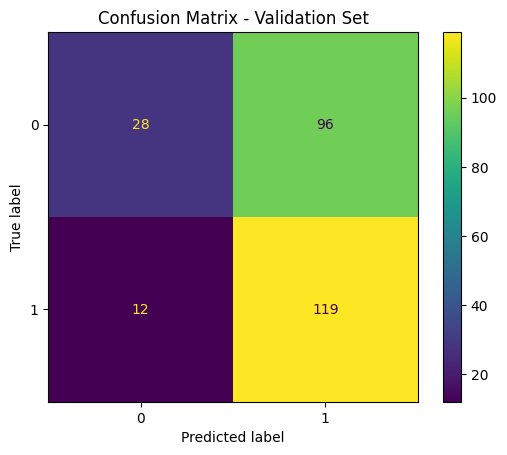

              precision    recall  f1-score     support
0              0.700000  0.225806  0.341463  124.000000
1              0.553488  0.908397  0.687861  131.000000
accuracy       0.576471  0.576471  0.576471    0.576471
macro avg      0.626744  0.567102  0.514662  255.000000
weighted avg   0.624733  0.576471  0.519417  255.000000


In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Predict on validation set
y_val_pred = best_model.predict(X_val)

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Classification report as table
# -----------------------------
report_dict = classification_report(y_val, y_val_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

print(report_df)

## 7.3 Priortitazing F1-macro

In [16]:
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# -----------------------------
# Build the machine learning pipeline
# -----------------------------
# Step 1: Standardize the features so they have comparable scale
# Step 2: Train an SVM with RBF kernel
# class_weight="balanced" gives more importance to the minority class
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# -----------------------------
# Define temporal cross-validation
# -----------------------------
# TimeSeriesSplit preserves chronological order:
# earlier samples are used for training, later samples for validation
# This is important to avoid temporal leakage
tscv = TimeSeriesSplit(n_splits=4)

# -----------------------------
# Define the hyperparameter search space
# -----------------------------
# C controls how strongly the model penalizes misclassification
# gamma controls how flexible the RBF decision boundary is
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# -----------------------------
# Set up grid search
# -----------------------------
# GridSearchCV will try all combinations of C and gamma
# scoring="accuracy" means models are ranked by mean validation accuracy
# cv=tscv applies temporal cross-validation
# n_jobs=-1 uses all available CPU cores
# refit=True retrains the best model on the full training set at the end
grid_acc = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# -----------------------------
# Fit grid search on the training set only
# -----------------------------
# This tests all parameter combinations using temporal CV
grid_acc.fit(X_train, y_train)

# -----------------------------
# Retrieve the best model
# -----------------------------
# best_estimator_ contains the pipeline with the best hyperparameters found
best_model_acc = grid_acc.best_estimator_

# Print the best hyperparameters
print("Best parameters (f1_macro):")
print(grid_acc.best_params_)

# Print the best mean cross-validation accuracy
print("\nBest mean CV f1_macro:")
print(grid_acc.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters (accuracy):
{'svm__C': 10, 'svm__gamma': 0.01}

Best mean CV accuracy:
0.6143909689463845


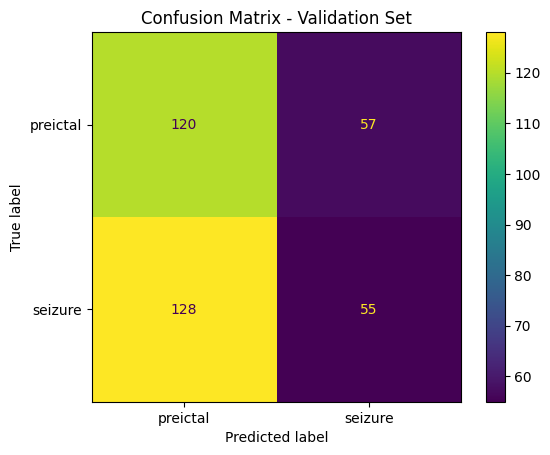

              precision  recall  f1-score  support
preictal          0.484   0.678     0.565  177.000
seizure           0.491   0.301     0.373  183.000
accuracy          0.486   0.486     0.486    0.486
macro avg         0.487   0.489     0.469  360.000
weighted avg      0.488   0.486     0.467  360.000


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# Predict on validation set
y_val_pred = best_model_acc.predict(X_val)

# Correct class names
class_names = ["preictal", "seizure"]

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Classification report as table
# -----------------------------
report_dict = classification_report(
    y_val,
    y_val_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose().round(3)
print(report_df)

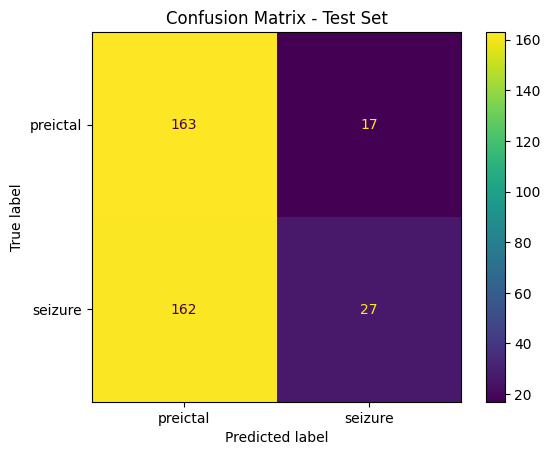

              precision  recall  f1-score  support
preictal          0.502   0.906     0.646  180.000
seizure           0.614   0.143     0.232  189.000
accuracy          0.515   0.515     0.515    0.515
macro avg         0.558   0.524     0.439  369.000
weighted avg      0.559   0.515     0.434  369.000


In [29]:
# Predict on test set
y_test_pred = best_model_acc.predict(X_test)

# Confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=class_names)
disp_test.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# Classification report
report_test = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

report_test_df = pd.DataFrame(report_test).transpose().round(3)
print(report_test_df)

## 8. Removing redundant features and trying again:

In [19]:
import numpy as np
import pandas as pd

# -----------------------------
# Step 1: Remove constant columns
# -----------------------------
# These features have no variation and therefore no predictive value
constant_cols = [col for col in X_train.columns if X_train[col].nunique() <= 1]

print("Constant columns:")
print(constant_cols)

# Drop constant columns from train/val/test
X_train_red = X_train.drop(columns=constant_cols).copy()
X_val_red = X_val.drop(columns=constant_cols).copy()
X_test_red = X_test.drop(columns=constant_cols).copy()

# -----------------------------
# Step 2: Remove highly correlated columns
# -----------------------------
# Compute absolute correlation matrix only on the training set
corr_matrix = X_train_red.corr().abs()

# Keep only the upper triangle of the correlation matrix
# to avoid checking each pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Select columns with correlation above the chosen threshold
# Common thresholds: 0.90, 0.95, 0.98
corr_threshold = 0.95
high_corr_cols = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print("\nHighly correlated columns to remove:")
print(high_corr_cols)

# Drop highly correlated columns from all sets
X_train_red = X_train_red.drop(columns=high_corr_cols).copy()
X_val_red = X_val_red.drop(columns=high_corr_cols).copy()
X_test_red = X_test_red.drop(columns=high_corr_cols).copy()

# -----------------------------
# Step 3: Check final shapes
# -----------------------------
print("\nOriginal X_train shape:", X_train.shape)
print("Reduced X_train shape:", X_train_red.shape)

print("\nFinal features kept:")
print(X_train_red.columns.tolist())

Constant columns:
[]

Highly correlated columns to remove:
['rms_EEG_SQ_D_SQ_C', 'ptp_EEG_SQ_D_SQ_C', 'rms_EEG_SQ_P_SQ_C', 'beta_power_EEG_SQ_P_SQ_C']

Original X_train shape: (1714, 28)
Reduced X_train shape: (1714, 24)

Final features kept:
['mean_EEG_SQ_D_SQ_C', 'std_EEG_SQ_D_SQ_C', 'var_EEG_SQ_D_SQ_C', 'line_length_EEG_SQ_D_SQ_C', 'skew_EEG_SQ_D_SQ_C', 'kurtosis_EEG_SQ_D_SQ_C', 'mean_EEG_SQ_P_SQ_C', 'std_EEG_SQ_P_SQ_C', 'var_EEG_SQ_P_SQ_C', 'ptp_EEG_SQ_P_SQ_C', 'line_length_EEG_SQ_P_SQ_C', 'skew_EEG_SQ_P_SQ_C', 'kurtosis_EEG_SQ_P_SQ_C', 'delta_power_EEG_SQ_D_SQ_C', 'theta_power_EEG_SQ_D_SQ_C', 'alpha_power_EEG_SQ_D_SQ_C', 'beta_power_EEG_SQ_D_SQ_C', 'gamma_power_EEG_SQ_D_SQ_C', 'peak_frequency_EEG_SQ_D_SQ_C', 'delta_power_EEG_SQ_P_SQ_C', 'theta_power_EEG_SQ_P_SQ_C', 'alpha_power_EEG_SQ_P_SQ_C', 'gamma_power_EEG_SQ_P_SQ_C', 'peak_frequency_EEG_SQ_P_SQ_C']


In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Build pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced"))
])

# Temporal cross-validation
tscv = TimeSeriesSplit(n_splits=4)

# Hyperparameter grid
param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

# Grid search using accuracy
grid_acc_red = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Fit on reduced training set
grid_acc_red.fit(X_train_red, y_train)

# Best reduced model
best_model_acc_red = grid_acc_red.best_estimator_

print("Best parameters (reduced features):")
print(grid_acc_red.best_params_)

print("\nBest mean CV accuracy (reduced features):")
print(grid_acc_red.best_score_)

Fitting 4 folds for each of 20 candidates, totalling 80 fits
Best parameters (reduced features):
{'svm__C': 10, 'svm__gamma': 0.01}

Best mean CV accuracy (reduced features):
0.6366959064327485


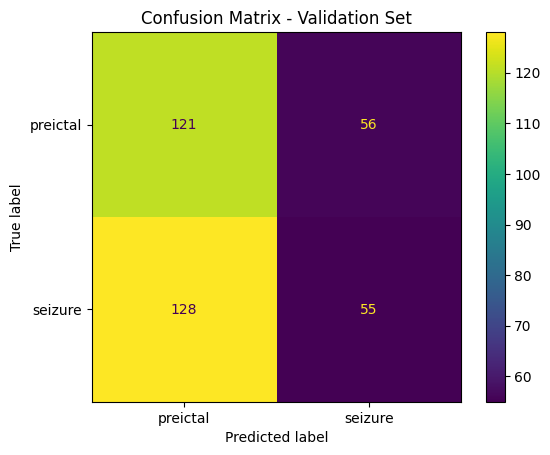

Classification Report - Validation Set
              precision  recall  f1-score  support
preictal          0.486   0.684     0.568  177.000
seizure           0.495   0.301     0.374  183.000
accuracy          0.489   0.489     0.489    0.489
macro avg         0.491   0.492     0.471  360.000
weighted avg      0.491   0.489     0.469  360.000


In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Predict on the validation set
# -----------------------------
y_val_pred = best_model_acc_red.predict(X_val_red)

# Define class names according to your mapping
# 0 = preictal
# 1 = seizure
class_names = ["preictal", "seizure"]

# -----------------------------
# Compute and plot confusion matrix
# -----------------------------
cm = confusion_matrix(y_val, y_val_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

# -----------------------------
# Generate classification report
# -----------------------------
report_dict = classification_report(
    y_val,
    y_val_pred,
    target_names=class_names,
    output_dict=True
)

# Convert report to a dataframe for cleaner display
report_df = pd.DataFrame(report_dict).transpose().round(3)

print("Classification Report - Validation Set")
print(report_df)

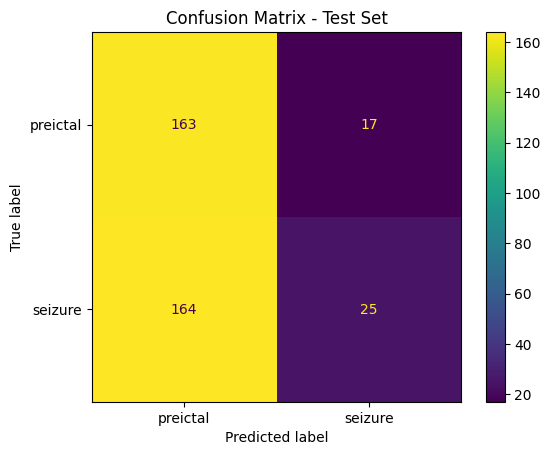

Classification Report - Test Set
              precision  recall  f1-score  support
preictal          0.498   0.906     0.643  180.000
seizure           0.595   0.132     0.216  189.000
accuracy          0.509   0.509     0.509    0.509
macro avg         0.547   0.519     0.430  369.000
weighted avg      0.548   0.509     0.425  369.000


In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Predict on the test set
# -----------------------------
y_test_pred = best_model_acc_red.predict(X_test_red)

# Define class names
# 0 = preictal
# 1 = seizure
class_names = ["preictal", "seizure"]

# -----------------------------
# Compute and plot confusion matrix
# -----------------------------
cm_test = confusion_matrix(y_test, y_test_pred)

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=class_names
)

disp_test.plot()
plt.title("Confusion Matrix - Test Set")
plt.show()

# -----------------------------
# Generate classification report
# -----------------------------
report_dict_test = classification_report(
    y_test,
    y_test_pred,
    target_names=class_names,
    output_dict=True
)

# Convert report to dataframe
report_df_test = pd.DataFrame(report_dict_test).transpose().round(3)

print("Classification Report - Test Set")
print(report_df_test)

## 9. NEW optimization SVM

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    fbeta_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix
)

# -----------------------------
# Build the machine learning pipeline
# -----------------------------
window_sec = 10
gap_min = 5
gap_windows = int((gap_min * 60) / window_sec)

tscv = TimeSeriesSplit(n_splits=4, gap=gap_windows)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

# -----------------------------
# Temporal cross-validation
# -----------------------------
# Each row = one 10-second window.
# Therefore, a 5-minute gap = 30 windows.
tscv = TimeSeriesSplit(n_splits=4, gap=gap_windows)

print("CV gap in windows:", gap_windows)
# -----------------------------
# Define multiple evaluation metrics
# -----------------------------
scoring = {
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy",
    "recall_seizure": make_scorer(recall_score, pos_label=1),
    "precision_seizure": make_scorer(precision_score, pos_label=1, zero_division=0),
    "f2_seizure": make_scorer(fbeta_score, beta=2, pos_label=1)
}

# -----------------------------
# Define hyperparameter search space
# -----------------------------
param_grid = {
    "svm__C": np.logspace(-2, 3, 6),
    "svm__gamma": ["scale"] + list(np.logspace(-4, 0, 5)),
    "svm__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5},
        {0: 1, 1: 10}
    ]
}

# -----------------------------
# Grid search
# -----------------------------
grid_f2 = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit="f2_seizure",
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

# -----------------------------
# Fit only on training set
# -----------------------------
grid_f2.fit(X_train, y_train)

# -----------------------------
# Best model
# -----------------------------
best_model_f2 = grid_f2.best_estimator_

print("Best parameters based on f2_macro:")
print(grid_f2.best_params_)

print("\nBest mean CV f2_macro:")
print(grid_f2.best_score_)

Fitting 4 folds for each of 216 candidates, totalling 864 fits
Best parameters based on f2_macro:
{'svm__C': np.float64(0.1), 'svm__class_weight': {0: 1, 1: 3}, 'svm__gamma': 'scale'}

Best mean CV f2_macro:
0.8384398871680431


Si quieres seizure screening:
    alto recall está bien, aunque haya falsos positivos.

Si quieres clasificación balanceada:
    necesitas subir el threshold para reducir falsos positivos.

Si quieres predicción útil:
    necesitas buen recall, pero también controlar false alarm rate.

In [45]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

# -----------------------------
# Threshold sweep on validation set
# -----------------------------
val_scores = best_model_f2.decision_function(X_val)

threshold_values = np.linspace(
    val_scores.min(),
    val_scores.max(),
    200
)

rows = []

for thr in threshold_values:
    y_val_pred_thr = (val_scores >= thr).astype(int)

    precision_seizure = precision_score(
        y_val, y_val_pred_thr, pos_label=1, zero_division=0
    )
    recall_seizure = recall_score(
        y_val, y_val_pred_thr, pos_label=1, zero_division=0
    )
    recall_preictal = recall_score(
        y_val, y_val_pred_thr, pos_label=0, zero_division=0
    )
    f1_seizure = f1_score(
        y_val, y_val_pred_thr, pos_label=1, zero_division=0
    )
    f2_seizure = fbeta_score(
        y_val, y_val_pred_thr, beta=2, pos_label=1, zero_division=0
    )
    bal_acc = balanced_accuracy_score(y_val, y_val_pred_thr)

    tn, fp, fn, tp = confusion_matrix(
        y_val, y_val_pred_thr, labels=[0, 1]
    ).ravel()

    rows.append({
        "threshold": thr,
        "precision_seizure": precision_seizure,
        "recall_seizure": recall_seizure,
        "recall_preictal": recall_preictal,
        "f1_seizure": f1_seizure,
        "f2_seizure": f2_seizure,
        "balanced_accuracy": bal_acc,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

df_thresholds = pd.DataFrame(rows)

df_thresholds.sort_values(
    by="balanced_accuracy",
    ascending=False
).head(20)

,threshold,precision_seizure,recall_seizure,recall_preictal,f1_seizure,f2_seizure,balanced_accuracy,TN,FP,FN,TP
149,0.978559,0.541538,0.961749,0.158192,0.692913,0.832545,0.559970,28,149,7,176
150,0.979300,0.541538,0.961749,0.158192,0.692913,0.832545,0.559970,28,149,7,176
145,0.975594,0.541284,0.967213,0.152542,0.694118,0.835694,0.559878,27,150,6,177
157,0.984490,0.540373,0.950820,0.163842,0.689109,0.825427,0.557331,29,148,9,174
153,0.981524,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175
154,0.982266,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175
152,0.980783,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175
151,0.980042,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175
156,0.983748,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175
155,0.983007,0.540123,0.956284,0.158192,0.690335,0.828598,0.557238,28,149,8,175



Validation classification report:
              precision    recall  f1-score   support

    preictal       0.80      0.16      0.26       177
     seizure       0.54      0.96      0.69       183

    accuracy                           0.57       360
   macro avg       0.67      0.56      0.48       360
weighted avg       0.67      0.57      0.48       360



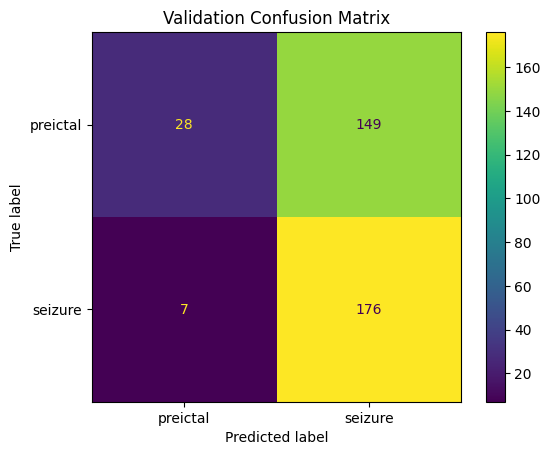

In [43]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# -----------------------------
# Validation evaluation using selected threshold
# -----------------------------
val_scores = best_model_f2.decision_function(X_val)
y_val_pred = (val_scores >= best_threshold).astype(int)

print("\nValidation classification report:")
print(classification_report(
    y_val,
    y_val_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))

cm_val = confusion_matrix(y_val, y_val_pred, labels=[0, 1])

disp_val = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["preictal", "seizure"]
)

disp_val.plot(values_format="d")
plt.title("Validation Confusion Matrix")
plt.show()


Test classification report:
              precision    recall  f1-score   support

    preictal       0.46      0.13      0.21       180
     seizure       0.51      0.85      0.64       189

    accuracy                           0.50       369
   macro avg       0.48      0.49      0.42       369
weighted avg       0.49      0.50      0.43       369



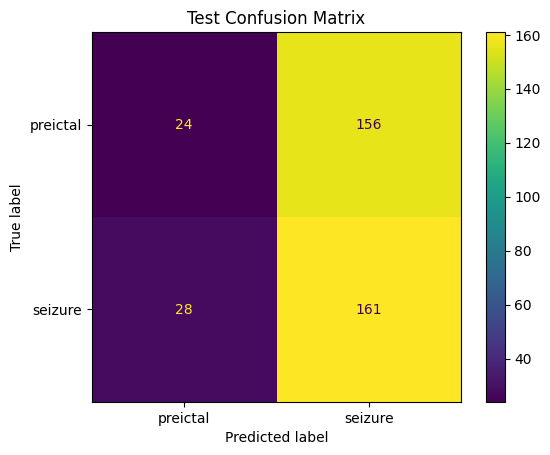

In [44]:
# -----------------------------
# Test evaluation using selected threshold
# -----------------------------
test_scores = best_model_f2.decision_function(X_test)
y_test_pred = (test_scores >= best_threshold).astype(int)

print("\nTest classification report:")
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))

cm_test = confusion_matrix(y_test, y_test_pred, labels=[0, 1])

disp_test = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=["preictal", "seizure"]
)

disp_test.plot(values_format="d")
plt.title("Test Confusion Matrix")
plt.show()

## dummy classifier

In [46]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score

# -----------------------------
# Dummy baseline: most frequent class
# -----------------------------
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_val_dummy = dummy.predict(X_val)
y_test_dummy = dummy.predict(X_test)

print("DUMMY VALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_dummy))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_val_dummy))
print(confusion_matrix(y_val, y_val_dummy, labels=[0, 1]))

print("\nDUMMY TEST")
print("Accuracy:", accuracy_score(y_test, y_test_dummy))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_dummy))
print(confusion_matrix(y_test, y_test_dummy, labels=[0, 1]))

DUMMY VALIDATION
Accuracy: 0.5083333333333333
Balanced accuracy: 0.5
[[  0 177]
 [  0 183]]

DUMMY TEST
Accuracy: 0.5121951219512195
Balanced accuracy: 0.5
[[  0 180]
 [  0 189]]


### Logistic regression

A Logistic Regression model is a simple supervised machine learning algorithm commonly used for binary classification problems. Instead of directly predicting a continuous value, it estimates the probability that a sample belongs to a given class, for example preictal or seizure. It does this by learning a weighted combination of the input features and then transforming the result into a probability between 0 and 1. Although it is called “regression”, it is mainly used as a classification model and often serves as a useful baseline because it is simple, interpretable, and easy to compare against more complex models.

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score

# -----------------------------
# Simple baseline model
# -----------------------------
baseline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight=None,
        random_state=42
    ))
])

# -----------------------------
# Train only on training set
# -----------------------------
baseline_lr.fit(X_train, y_train)

# -----------------------------
# Validation evaluation
# -----------------------------
y_val_pred = baseline_lr.predict(X_val)

print("LOGISTIC REGRESSION BASELINE - VALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_val_pred))

print(classification_report(
    y_val,
    y_val_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred, labels=[0, 1]))

# -----------------------------
# Test evaluation
# -----------------------------
y_test_pred = baseline_lr.predict(X_test)

print("\nLOGISTIC REGRESSION BASELINE - TEST")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))

print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))

print("Test confusion matrix:")
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

LOGISTIC REGRESSION BASELINE - VALIDATION
Accuracy: 0.4888888888888889
Balanced accuracy: 0.4911549504491989
              precision    recall  f1-score   support

    preictal       0.48      0.63      0.55       177
     seizure       0.50      0.36      0.41       183

    accuracy                           0.49       360
   macro avg       0.49      0.49      0.48       360
weighted avg       0.49      0.49      0.48       360

Validation confusion matrix:
[[111  66]
 [118  65]]

LOGISTIC REGRESSION BASELINE - TEST
Accuracy: 0.5040650406504065
Balanced accuracy: 0.5111111111111111
              precision    recall  f1-score   support

    preictal       0.49      0.80      0.61       180
     seizure       0.54      0.22      0.31       189

    accuracy                           0.50       369
   macro avg       0.52      0.51      0.46       369
weighted avg       0.52      0.50      0.46       369

Test confusion matrix:
[[144  36]
 [147  42]]


### SVM LINEAR

In [48]:
from sklearn.svm import LinearSVC

baseline_linear_svm = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearSVC(
        C=1.0,
        class_weight=None,
        max_iter=10000,
        random_state=42
    ))
])

baseline_linear_svm.fit(X_train, y_train)

y_val_pred = baseline_linear_svm.predict(X_val)
y_test_pred = baseline_linear_svm.predict(X_test)

print("LINEAR SVM BASELINE - VALIDATION")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print(classification_report(
    y_val,
    y_val_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))
print(confusion_matrix(y_val, y_val_pred, labels=[0, 1]))

print("\nLINEAR SVM BASELINE - TEST")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_test_pred))
print(classification_report(
    y_test,
    y_test_pred,
    labels=[0, 1],
    target_names=["preictal", "seizure"],
    zero_division=0
))
print(confusion_matrix(y_test, y_test_pred, labels=[0, 1]))

LINEAR SVM BASELINE - VALIDATION
Accuracy: 0.4861111111111111
Balanced accuracy: 0.4887931832916551
              precision    recall  f1-score   support

    preictal       0.48      0.65      0.55       177
     seizure       0.49      0.33      0.39       183

    accuracy                           0.49       360
   macro avg       0.49      0.49      0.47       360
weighted avg       0.49      0.49      0.47       360

[[115  62]
 [123  60]]

LINEAR SVM BASELINE - TEST
Accuracy: 0.5013550135501355
Balanced accuracy: 0.5083333333333333
              precision    recall  f1-score   support

    preictal       0.49      0.79      0.61       180
     seizure       0.53      0.22      0.31       189

    accuracy                           0.50       369
   macro avg       0.51      0.51      0.46       369
weighted avg       0.51      0.50      0.46       369

[[143  37]
 [147  42]]
